In [67]:
import cupy as cp
import math
import matplotlib.pyplot as plt
from model.network import Network

## Loading the Data

In [68]:
training_path = "input/training.txt"
validation_path = "input/validation.txt"

with open(training_path, "r", encoding="utf-8") as file:
    training_data = file.read()

with open(validation_path, "r", encoding="utf-8") as file:
    validation_data = file.read()

training_data = list(training_data)
validation_data = list(validation_data)

x_train = training_data[:-1]
y_train = training_data[1:]

x_test = validation_data[:-1]
y_test = validation_data[1:]

print(f"Training data length: X={len(x_train)}, Y={len(y_train)}")
print(f"Validation data length: X={len(x_test)}, Y={len(y_test)}")

Training data length: X=907158, Y=907158
Validation data length: X=208231, Y=208231


In [69]:
vocabulary = sorted(set(training_data).union(set(validation_data)))
print(f"Vocabulary size: {len(vocabulary)}")

Vocabulary size: 65


In [70]:
def char_to_index(char: str) -> int:
    return vocabulary.index(char)

def index_to_char(index: int) -> str:
    return vocabulary[index]

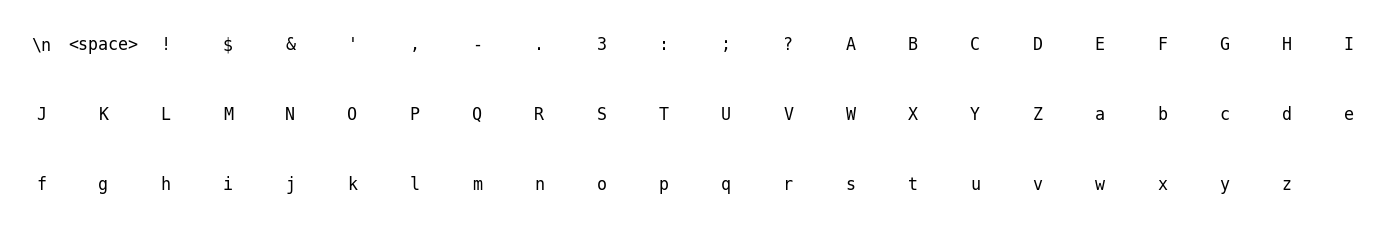

In [71]:
cols = 22
rows = math.ceil(len(vocabulary) / cols)

fig, ax = plt.subplots(figsize=(14, max(2, rows * 0.8)))

for index, token in enumerate(vocabulary):
    row, col = divmod(index, cols)
    display_token = {" ": "<space>", "\n": "\\n", "\t": "\\t"}.get(token, token)
    y = rows - row - 1
    ax.text(col, y, display_token, ha="center", va="center", fontsize=12, family="monospace")

ax.set_xlim(-0.5, cols - 0.5)
ax.set_ylim(-0.5, rows - 0.5)
ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.grid(True, linestyle=":", alpha=0.3)
plt.axis("off")
plt.tight_layout()
plt.show()

In [72]:
x_train_indices = cp.asarray([char_to_index(char) for char in x_train], dtype=cp.int32)
y_train_indices = cp.asarray([char_to_index(char) for char in y_train], dtype=cp.int32)
x_test_indices = cp.asarray([char_to_index(char) for char in x_test], dtype=cp.int32)
y_test_indices = cp.asarray([char_to_index(char) for char in y_test], dtype=cp.int32)

## Building the Model

In [73]:
embedding_dim = 64
hidden_size = 128

embeddings = cp.random.randn(len(vocabulary), embedding_dim).astype(cp.float32) * 0.01

layer_definitions = [
    {"type": "Recurrent", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "Softmax", "input_size": hidden_size, "num_neurons": len(vocabulary)},
]

network = Network(layer_definitions=layer_definitions)
network.describe()

Network Architecture

Layer 1: RecurrentLayer
  Weights Shape: (64, 128) | State Weights Shape: (128, 128) | Biases Shape: (128,)
  Parameters: 24,704

Layer 2: SoftmaxLayer
  Weights Shape: (128, 65) | Biases Shape: (65,)
  Parameters: 8,385

Total Parameters: 33,089


## Training the Model

In [74]:
sequence_length = 128
batch_size = 64
epochs = 200
train_steps_per_epoch = 3072
validation_steps = 1024
base_learning_rate = 0.006
min_learning_rate = 0.0003
weight_decay_lambda = 1e-4

print(f"Embeddings shape: {embeddings.shape}")
print(f"Training tokens: {x_train_indices.shape[0]}")
print(f"Validation tokens: {x_test_indices.shape[0]}")
print(f"Train steps per epoch: {train_steps_per_epoch}")
print(f"Validation steps: {validation_steps}")
print(f"Base learning rate: {base_learning_rate}")
print(f"Minimum learning rate: {min_learning_rate}")
print(f"Weight decay lambda: {weight_decay_lambda}")

Embeddings shape: (65, 64)
Training tokens: 907158
Validation tokens: 208231
Train steps per epoch: 3072
Validation steps: 1024
Base learning rate: 0.006
Minimum learning rate: 0.0003
Weight decay lambda: 0.0001


In [75]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [76]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [ ]:
def evaluate(
    network: Network,
    embeddings: cp.ndarray,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> tuple[float, float]:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]
    correct_predictions = 0

    for step in range(total_steps):
        x_embeddings = embeddings[x[:, step]]
        y_prob = network.forward(x_embeddings)[-1]
        y_true_idx = y[:, step]

        pred_idx = cp.argmax(y_prob, axis=1)
        correct_predictions += int(cp.sum(pred_idx == y_true_idx).item())

        y_true = one_hot(y_true_idx, len(vocabulary))
        total_loss += float(network.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            network.reset_states(batch_size=batch_size, dtype=cp.float32)

    avg_loss = total_loss / total_steps
    accuracy = correct_predictions / (total_steps * batch_size)
    return avg_loss, accuracy

In [ ]:
def train_epoch(
    network: Network,
    embeddings: cp.ndarray,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    max_steps: int | None = None,
    weight_decay_lambda: float = 0.0,
 ) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        x_batch = x[:, step]
        y_batch = y[:, step]
        x_embeddings = embeddings[x_batch]

        outputs = network.forward(x_embeddings)
        y_prob = outputs[-1]
        y_true = one_hot(y_batch, len(vocabulary))
        loss = network.cce_loss(y_prob, y_true)
        total_loss += float(loss.item())

        output_error = y_prob - y_true
        input_error = network.backward(output_error=output_error, batch_size=x_batch.shape[0])[-1]

        network.update_parameters(
            learning_rate=learning_rate,
            weight_decay_lambda=weight_decay_lambda,
        )
        cp.add.at(embeddings, x_batch, -learning_rate * input_error)

        if (step + 1) % sequence_length == 0:
            network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return total_loss / total_steps

In [79]:
epoch_summaries = []

total_steps = epochs * train_steps_per_epoch
global_step = 0

for epoch in range(1, epochs + 1):
    learning_rate = min_learning_rate + 0.5 * (base_learning_rate - min_learning_rate) * (1 + math.cos(math.pi * global_step / total_steps))

    train_loss = train_epoch(
        network=network,
        embeddings=embeddings,
        x_indices=x_train_indices,
        y_indices=y_train_indices,
        batch_size=batch_size,
        sequence_length=sequence_length,
        learning_rate=learning_rate,
        max_steps=train_steps_per_epoch,
        weight_decay_lambda=weight_decay_lambda,
    )
    test_loss, test_accuracy = evaluate(
        network=network,
        embeddings=embeddings,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=batch_size,
        sequence_length=sequence_length,
        max_steps=validation_steps,
    )

    epoch_summary = {
        "epoch": epoch + 1,
        "learning_rate": learning_rate,
        "train_loss": train_loss,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy
    }
    epoch_summaries.append(epoch_summary)
    print(epoch_summary)
    global_step += train_steps_per_epoch

{'epoch': 2, 'learning_rate': 0.006, 'train_loss': 2.7654854551204373, 'test_loss': 2.4918586963178586, 'test_accuracy': 0.3137054443359375}
{'epoch': 3, 'learning_rate': 0.005999648402572733, 'train_loss': 2.369942005161261, 'test_loss': 2.345574647294498, 'test_accuracy': 0.3419647216796875}
{'epoch': 4, 'learning_rate': 0.005998593697042335, 'train_loss': 2.255385757550185, 'test_loss': 2.268732414786786, 'test_accuracy': 0.35980224609375}
{'epoch': 5, 'learning_rate': 0.005996836143641615, 'train_loss': 2.186891652994284, 'test_loss': 2.2195115770001053, 'test_accuracy': 0.3679656982421875}
{'epoch': 6, 'learning_rate': 0.005994376176020574, 'train_loss': 2.1387140586538917, 'test_loss': 2.1842060084674135, 'test_accuracy': 0.375732421875}
{'epoch': 7, 'learning_rate': 0.005991214401139415, 'train_loss': 2.1017925390941454, 'test_loss': 2.1570757328292016, 'test_accuracy': 0.3796234130859375}
{'epoch': 8, 'learning_rate': 0.005987351599118778, 'train_loss': 2.0717929512661946, 'tes

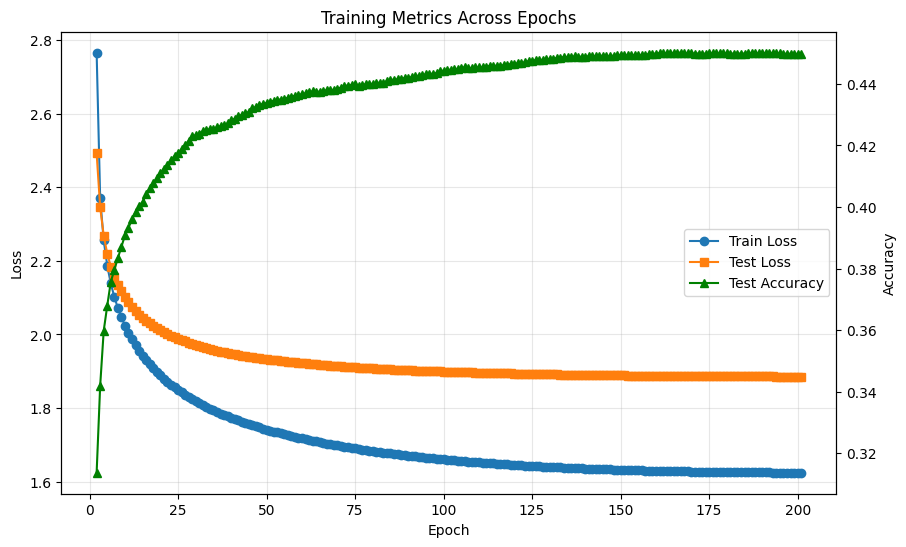

In [80]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_losses = [summary["train_loss"] for summary in epoch_summaries]
test_losses = [summary["test_loss"] for summary in epoch_summaries]
test_accuracies = [summary["test_accuracy"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

line1 = ax1.plot(epochs_plot, train_losses, marker="o", label="Train Loss")
line2 = ax1.plot(epochs_plot, test_losses, marker="s", label="Test Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
line3 = ax2.plot(epochs_plot, test_accuracies, marker="^", color="green", label="Test Accuracy")
ax2.set_ylabel("Accuracy")

lines = line1 + line2 + line3
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="center right")

plt.title("Training Metrics Across Epochs")
plt.show()

In [81]:
def generate_text(
    network: Network,
    embeddings: cp.ndarray,
    seed_text: str,
    length: int = 250,
    temperature: float = 0.8,
 ) -> str:
    network.reset_states(batch_size=1, dtype=cp.float32)
    generated = list(seed_text)

    for character in seed_text:
        token_index = cp.asarray([char_to_index(character)], dtype=cp.int32)
        x_embeddings = embeddings[token_index]
        network.forward(x_embeddings)

    current_character = seed_text[-1]

    for _ in range(length):
        token_index = cp.asarray([char_to_index(current_character)], dtype=cp.int32)
        x_embeddings = embeddings[token_index]
        outputs = network.forward(x_embeddings)
        y_prob = outputs[-1][0]
        log_prob = cp.log(y_prob + 1e-9) / temperature
        scaled_prob = cp.exp(log_prob - cp.max(log_prob))
        scaled_prob = scaled_prob / cp.sum(scaled_prob)
        next_index = int(
            cp.random.choice(len(vocabulary), size=1, p=scaled_prob)[0].item()
        )
        current_character = index_to_char(next_index)
        generated.append(current_character)

    return "".join(generated)

seed_text = "DANIEL"
print(generate_text(network=network, embeddings=embeddings, seed_text=seed_text, length=1000, temperature=0.75))

DANIELAND:
No man too that had to my lose her most your of no proclence not heart of I souse thou artice, and all neave see the unde-fort recce and forture an our abalingning new well.

RORCINGBROYD:
I bleereisfessan
the dead, and lone. and the not the death the can what hath are how will bear own the for the cutter a such the granger haguest you become than ento thing.

Second eases of the land yet thy his lord!

ROMEO:
So the do a with end would my weep Keell that had sainst heaven to my for the mine,
Which make than a grannow no him not beth
Reave the lady mander.

ROMEO:
Your thee to the yound.

Clown:
That I the were a such with the know the vill heart nothing hellow'd that my see if the more your good men.

DUCKINGHRY:
AQULIET:
Then.

KING HENRY SI:
I crood bid in the good with spear,
Lut should good mele but grame remen not they strumber for you the brother.

AUTOLUS:

QUEER:
Even even and I coublinghan; flatuse and then that a stand with not we will how the fortep you, lent not